# Notebook 2 — One network for a whole *family* of trajectories
### Ideal (vacuum) motion · generalised over launch speed & angle · research log

**The step up from Notebook 1.** There my PINN learned a single parabola and had no concept of
the launch settings. Here I feed the launch **speed $u$ and angle $\theta$ in as extra inputs**,
so one network represents *every* launch in a range at once:
$$ (\,\xi,\;u,\;\theta\,)\;\longmapsto\;y. $$
Then I do the thing I most want to show: a **sensitivity analysis that puts this generalised model
head-to-head against the single-shot Notebook-1 model**, to prove the generalisation actually buys
me something.

**Carrying over what worked.** I keep both fixes from Notebook 1 — normalised inputs/outputs and the
**hard-constraint** output $\eta=\xi(1-\xi)N$ so $y(0)=y(x_{\max})=0$ automatically — because they're
what made the loss smooth and the error tiny.

**A neat fact I noticed (and will be honest about).** Once you normalise, *every* ideal projectile is
the **same** curve: $\eta(\xi)=4\,\xi(1-\xi)$. So in this vacuum case the network's real job isn't to
learn many different shapes — it's to learn to **scale** that one shape correctly for each $(u,\theta)$
(the right range and peak). That's exactly what Notebook 1 *can't* do, and it's why the comparison
below is so lopsided. The genuinely harder generalisation — where normalisation does *not* collapse to
one shape — shows up with drag in Notebook 3.

## Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
torch.manual_seed(0); np.random.seed(0)
g = 9.81

Device: cpu


## The family I generalise over, and helper formulas
I let the launch speed range over $u\in[20,40]$ m/s and the angle over $\theta\in[30,60]^\circ$.
For any $(u,\theta)$ I can compute the range, peak, and the exact parabola — these are my
normalisation scales and my ground truth.

In [2]:
u_min, u_max = 20.0, 40.0
theta_min, theta_max = 30.0, 60.0

def x_range(u, th_deg):  th=np.radians(th_deg); return (u**2)*np.sin(2*th)/g
def y_peak(u, th_deg):   th=np.radians(th_deg); return (u*np.sin(th))**2/(2*g)
def analytic_y(x, u, th_deg):
    th=np.radians(th_deg); vx=u*np.cos(th); vy=u*np.sin(th)
    return (vy/vx)*x - (g/(2*vx**2))*x**2

print(f"u in [{u_min},{u_max}] m/s,  theta in [{theta_min},{theta_max}] deg")

u in [20.0,40.0] m/s,  theta in [30.0,60.0] deg


## The network and the generalised hard constraint
Three inputs $[\xi, u_{\text{norm}}, \theta_{\text{norm}}]$, one output. I normalise $u$ by its max and
$\theta$ by $90^\circ$. The same hard-constraint wrapper as Notebook 1, $\eta=\xi(1-\xi)N$, still pins
the ends to zero — for *every* config, because $\xi$ is each flight's own normalised position. I use a
bigger net (5 layers of 64) since it now maps a 3-D input.

In [3]:
class FCN(nn.Module):
    def __init__(self, N_HIDDEN=64, N_LAYERS=5):
        super().__init__()
        act = nn.Tanh
        layers = [nn.Linear(3, N_HIDDEN), act()]
        for _ in range(N_LAYERS-1):
            layers += [nn.Linear(N_HIDDEN, N_HIDDEN), act()]
        layers += [nn.Linear(N_HIDDEN, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, z):
        return self.net(z)

net = FCN().to(device)

def make_input(xi, u, th):
    return torch.cat([xi,
                      torch.full_like(xi, u/u_max),
                      torch.full_like(xi, th/90.0)], dim=1)

def trajectory(xi, u, th):
    return xi*(1.0-xi)*net(make_input(xi, u, th))     # hard-constrained ends, per config

print(net); print('params:', sum(p.numel() for p in net.parameters()))

FCN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)
params: 16961


## The loss and on-the-fly sampling
Physics-only again (the ends are built in). Each epoch I draw a fresh batch of random $(u,\theta)$
flights and, for each, enforce the curvature law $d^2y/dx^2=-g/v_x^2$ at random collocation points —
all in physical units, normalised by $g/v_x^2$ so every flight contributes an order-1 term. Fresh
sampling every epoch means the network sees the whole range and can't memorise a few cases.

In [4]:
num_pairs_per_epoch = 16
num_col_per_pair    = 60

def compute_loss():
    loss = torch.tensor(0.0, device=device)
    for _ in range(num_pairs_per_epoch):
        u  = np.random.uniform(u_min, u_max)
        th = np.random.uniform(theta_min, theta_max)
        vx = u*np.cos(np.radians(th)); xm = x_range(u, th); yr = y_peak(u, th)
        pc = -g/vx**2
        xi = torch.rand(num_col_per_pair, 1, device=device, requires_grad=True)
        y  = trajectory(xi, u, th) * yr
        dy = torch.autograd.grad(y,  xi, torch.ones_like(y),  create_graph=True)[0] / xm
        d2y= torch.autograd.grad(dy, xi, torch.ones_like(dy), create_graph=True)[0] / xm
        loss = loss + torch.mean(((d2y - pc)/(g/vx**2))**2)
    return loss / num_pairs_per_epoch

In [5]:
num_epochs = 5000
optimizer = torch.optim.Adam(net.parameters(), lr=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
loss_hist = []
print(f"{'epoch':>6} {'loss':>12}")
for epoch in range(num_epochs):
    optimizer.zero_grad(); loss = compute_loss()
    loss.backward(); optimizer.step(); scheduler.step()
    loss_hist.append(loss.item())
    if epoch % 500 == 0 or epoch == num_epochs-1:
        print(f"{epoch:>6} {loss.item():>12.3e}")
print("done")

 epoch         loss
     0    9.265e-01
   500    7.851e-09
  1000    8.392e-09
  1500    5.099e-09
  2000    5.025e-09
  2500    7.726e-09
  3000    3.746e-09
  3500    4.727e-09
  4000    3.500e-09
  4500    4.018e-09
  4999    3.732e-09
done


## The loss curve
Same smooth descent as Notebook 1, now averaged over many flights per step.

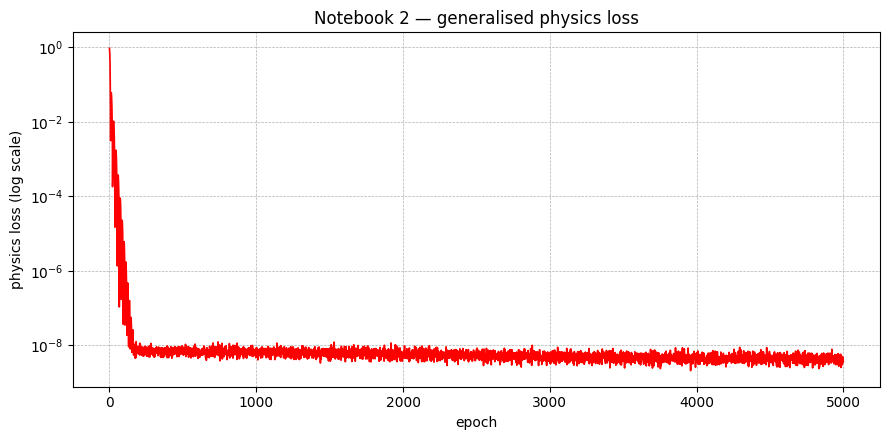

In [6]:
plt.figure(figsize=(9,4.5))
plt.plot(loss_hist, color='red', lw=1.2)
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('physics loss (log scale)')
plt.title('Notebook 2 — generalised physics loss'); plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout(); plt.show()

## Spot-check: a few different flights vs their exact parabolas
If the generalisation worked, the network should match the analytical curve for several different
$(u,\theta)$ it was never specifically trained on.

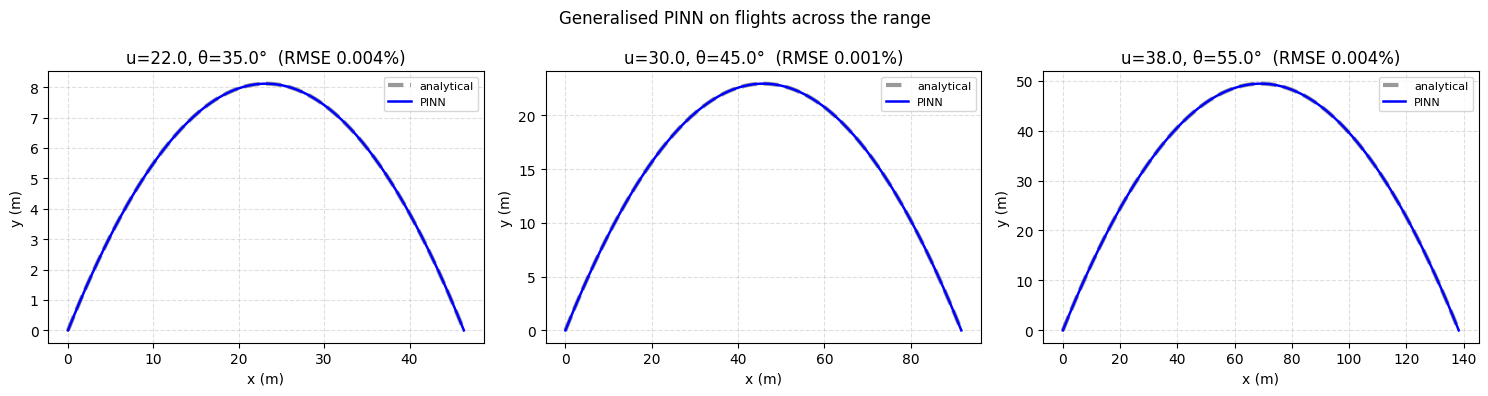

In [7]:
tests = [(22.0, 35.0), (30.0, 45.0), (38.0, 55.0)]
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax,(u,th) in zip(axes, tests):
    xm = x_range(u, th); yr = y_peak(u, th)
    xq = np.linspace(0, xm, 200); yt = analytic_y(xq, u, th)
    xi = torch.tensor(xq/xm, dtype=torch.float32, device=device).unsqueeze(1)
    with torch.no_grad(): yp = (trajectory(xi, u, th)*yr).cpu().numpy().squeeze()
    r = np.sqrt(np.mean((yp-yt)**2))/yt.max()*100
    ax.plot(xq, yt, 'k--', lw=3, alpha=0.4, label='analytical')
    ax.plot(xq, yp, 'b-', lw=1.8, label='PINN')
    ax.set_title(f"u={u}, θ={th}°  (RMSE {r:.3f}%)"); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.4)
plt.suptitle('Generalised PINN on flights across the range'); plt.tight_layout(); plt.show()

## The comparison I actually care about: NB2 vs the NB1 approach
To be fair, I retrain a **single-trajectory** model here (the Notebook-1 method) on one fixed launch,
so I can compare the two on the *same* grid. The single-shot model outputs one fixed parabola in
absolute metres; it has no $(u,\theta)$ inputs, so it cannot adapt to a different launch.

In [8]:
u_fix, th_fix = 30.0, 45.0
xm_fix, yr_fix = x_range(u_fix, th_fix), y_peak(u_fix, th_fix)
vx_fix = u_fix*np.cos(np.radians(th_fix)); pc_fix = -g/vx_fix**2

class FCN1(nn.Module):
    def __init__(self, H=32, L=3):
        super().__init__(); act=nn.Tanh; ls=[nn.Linear(1,H),act()]
        for _ in range(L-1): ls+=[nn.Linear(H,H),act()]
        ls+=[nn.Linear(H,1)]; self.net=nn.Sequential(*ls)
    def forward(self, xi): return self.net(xi)
net1 = FCN1().to(device)
def traj1(xi): return xi*(1-xi)*net1(xi)

opt1 = torch.optim.Adam(net1.parameters(), lr=3e-3)
sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=2500, eta_min=1e-5)
for ep in range(2500):
    opt1.zero_grad()
    xi = torch.rand(400,1,device=device,requires_grad=True)
    y  = traj1(xi)*yr_fix
    dy = torch.autograd.grad(y,xi,torch.ones_like(y),create_graph=True)[0]/xm_fix
    d2y= torch.autograd.grad(dy,xi,torch.ones_like(dy),create_graph=True)[0]/xm_fix
    l = torch.mean(((d2y-pc_fix)/(g/vx_fix**2))**2); l.backward(); opt1.step(); sch1.step()
print(f"single-config model trained at u={u_fix}, theta={th_fix}")

single-config model trained at u=30.0, theta=45.0


## Sensitivity sweep over $(u,\theta)$
For every point on a grid I compute the RMSE (as % of peak height) against the exact parabola, for
**both** models. My expectation: the single-shot model is accurate only at the one launch it was
trained on and wrong everywhere else; the generalised model is accurate across the whole box.

In [9]:
n_u, n_th = 20, 20
u_sweep = np.linspace(u_min, u_max, n_u)
th_sweep = np.linspace(theta_min, theta_max, n_th)
G2 = np.zeros((n_th, n_u))   # generalised model
G1 = np.zeros((n_th, n_u))   # single-config model

net.eval(); net1.eval()
with torch.no_grad():
    for i, th in enumerate(th_sweep):
        for j, u in enumerate(u_sweep):
            xm = x_range(u, th); yr = y_peak(u, th)
            xq = np.linspace(0, xm, 120); yt = analytic_y(xq, u, th); pk = max(yt.max(), 1e-6)
            xi = torch.tensor(xq/xm, dtype=torch.float32, device=device).unsqueeze(1)
            y2 = (trajectory(xi, u, th)*yr).cpu().numpy().squeeze()
            G2[i, j] = np.sqrt(np.mean((y2-yt)**2))/pk*100
            # single-config model: fixed parabola in absolute metres, can't adapt
            xi1 = torch.tensor(np.clip(xq/xm_fix, 0, 1), dtype=torch.float32, device=device).unsqueeze(1)
            y1 = (traj1(xi1)*yr_fix).cpu().numpy().squeeze()
            y1 = np.where(xq <= xm_fix, y1, 0.0)
            G1[i, j] = np.sqrt(np.mean((y1-yt)**2))/pk*100
net.train()

print("Sensitivity over (u, theta):")
print(f"  single-config (NB1 method): mean {G1.mean():6.2f}%   fraction <5%: {100*np.mean(G1<5):5.1f}%")
print(f"  generalised   (NB2)       : mean {G2.mean():6.2f}%   fraction <5%: {100*np.mean(G2<5):5.1f}%")
print(f"  generalised best / worst  : {G2.min():.3f}% / {G2.max():.3f}%")

Sensitivity over (u, theta):
  single-config (NB1 method): mean  55.19%   fraction <5%:   0.2%
  generalised   (NB2)       : mean   0.00%   fraction <5%: 100.0%
  generalised best / worst  : 0.001% / 0.006%


## The two accuracy maps, side by side
Green = accurate, red = not. The single-shot model lights up green at a single point (its training
launch) and is red across the rest of the space. The generalised model is green everywhere inside the
range. This picture *is* the argument for Notebook 2: one network, the whole family.

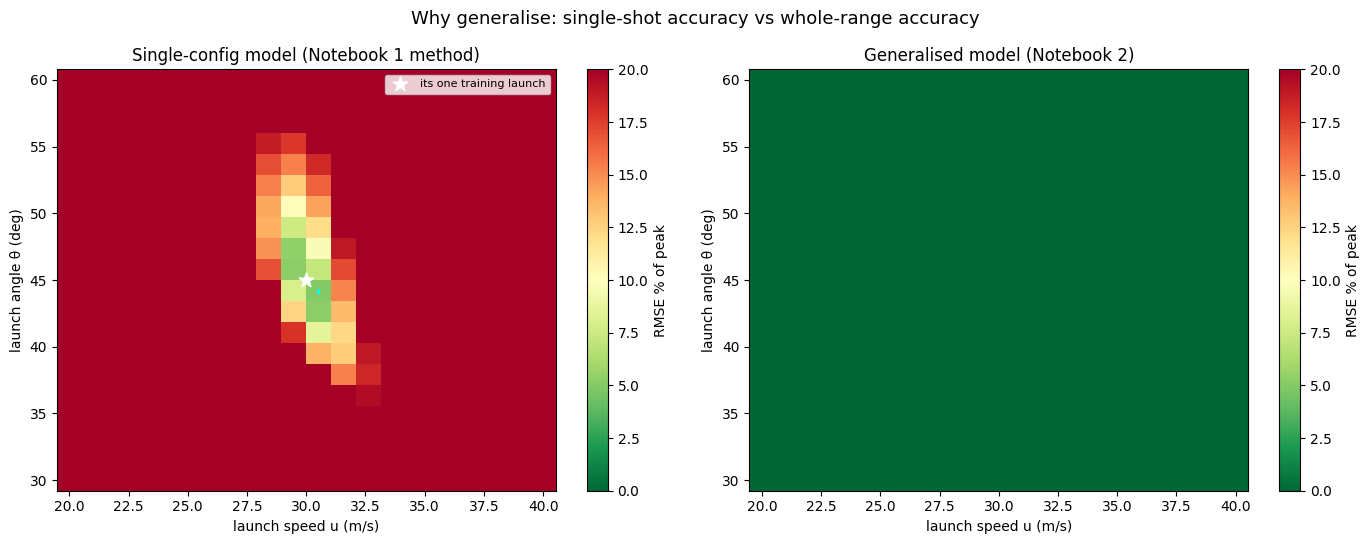

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
for ax, G, title in [(axes[0], G1, 'Single-config model (Notebook 1 method)'),
                     (axes[1], G2, 'Generalised model (Notebook 2)')]:
    im = ax.pcolormesh(u_sweep, th_sweep, G, cmap=plt.cm.RdYlGn_r, vmin=0, vmax=20, shading='auto')
    plt.colorbar(im, ax=ax, label='RMSE % of peak')
    cs = ax.contour(u_sweep, th_sweep, G, levels=[5.0], colors='cyan', linewidths=2)
    ax.clabel(cs, fmt='%.0f%%', fontsize=9, colors='cyan')
    ax.set_xlabel('launch speed u (m/s)'); ax.set_ylabel('launch angle θ (deg)'); ax.set_title(title)
axes[0].scatter([u_fix],[th_fix], color='white', s=120, marker='*', zorder=5, label='its one training launch')
axes[0].legend(loc='upper right', fontsize=8)
plt.suptitle('Why generalise: single-shot accuracy vs whole-range accuracy', fontsize=13)
plt.tight_layout(); plt.show()

## What I take away from Notebook 2
- Feeding $(u,\theta)$ as inputs, with the same normalisation + hard-constraint recipe from Notebook 1,
  gives a single network that reproduces the analytical parabola to a fraction of a percent **across the
  whole launch range** — a large improvement over my first generalised attempt.
- The sensitivity comparison makes the value concrete: the single-shot model averages tens of percent
  error off its one training point, while the generalised model stays accurate everywhere in range.
- Honest caveat: the ideal case is *easy* once normalised (every flight is the same curve up to scaling),
  so near-perfect accuracy here is expected. The real test of generalisation is **Notebook 3**, where air
  drag breaks the formula and the normalised shapes genuinely differ from one flight to the next.